# RNNS

En este notebook se prueba una **red recurrente simple (SimpleRNN)** sobre los distintos datasets preprocesados.

La idea es comparar:

```text
preprocesado + vectorización + RNN
```


## 1 - Imports

In [14]:
import pandas as pd
import numpy as np
import sys
import os
import gc
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, SimpleRNN, Masking
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../Code"))
import vectorize

In [15]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU disponible: []


## 2 - Configuración

In [16]:
DATA_PATHS = [
    '../Data/raw/tcga_simple_train.csv',
    '../Data/interim/tcga_simple_train_preprocessed_0.csv',
    '../Data/interim/tcga_simple_train_preprocessed_1.csv',
    '../Data/interim/tcga_simple_train_preprocessed_2.csv',
    '../Data/interim/tcga_simple_train_preprocessed_3.csv',
    '../Data/interim/tcga_simple_train_preprocessed_4.csv',
    '../Data/interim/tcga_simple_train_preprocessed_3_augmented.csv',
]

RESULTS_PATH = '../Results/Metrics/rnn.csv'
BEST_MODEL_PATH = '../Models/best_rnn.keras'

os.makedirs('../Results/Metrics', exist_ok=True)
os.makedirs('../Models', exist_ok=True)

MAX_LEN = 400
BATCH_SIZE = 32
EPOCHS = 20

# Si tarda demasiado, deja solo una o dos vectorizaciones.
vectorizadores = ["Binaria", "Frecuencia", "Tfidf", "Word2Vec", "FastText"]

print("Vectorizaciones a probar:", vectorizadores)

Vectorizaciones a probar: ['Binaria', 'Frecuencia', 'Tfidf', 'Word2Vec', 'FastText']


## 3 - Carga de embeddings

In [17]:
w2v_model = None
fasttext_model = None

if "Word2Vec" in vectorizadores:
    import gensim.downloader
    print("Cargando Word2Vec...")
    w2v_model = gensim.downloader.load('word2vec-google-news-300')
    print("Word2Vec cargado")

if "FastText" in vectorizadores:
    from gensim.models.fasttext import load_facebook_model
    fasttext_path = "../Models/wiki.simple.bin"

    if os.path.exists(fasttext_path):
        print("Cargando FastText...")
        fasttext_model = load_facebook_model(fasttext_path)
        print("FastText cargado")
    else:
        print("No se ha encontrado FastText en:", fasttext_path)
        print("Se elimina FastText de la lista de vectorizaciones")
        vectorizadores = [v for v in vectorizadores if v != "FastText"]

Cargando Word2Vec...
Word2Vec cargado
No se ha encontrado FastText en: ../Models/wiki.simple.bin
Se elimina FastText de la lista de vectorizaciones


## 4 - Funciones auxiliares

Para las vectorizaciones clásicas, se obtiene un vocabulario y se transforma cada informe en una secuencia de índices.

Para Word2Vec/FastText, se convierte cada informe en una matriz:

```
nº tokens x dimensión del embedding
```

Después se aplica padding hasta `MAX_LEN`, quedando:

```
nº documentos x MAX_LEN x dimensión del embedding
```

In [18]:
def texto_a_secuencia(serie_texto, mapping, max_len):
    """
    Convierte cada texto en una secuencia de índices a partir de un vocabulario.
    Esta parte se usa con Binaria, Frecuencia y TF-IDF.
    """
    secuencias = []

    for texto in serie_texto.astype(str):
        seq = [mapping[w] for w in texto.split() if w in mapping]
        secuencias.append(seq)

    return pad_sequences(secuencias, maxlen=max_len, padding="post", truncating="post")


def obtener_keyed_vectors(modelo):
    """
    Devuelve el objeto que realmente contiene los vectores.
    """
    if hasattr(modelo, "wv"):
        return modelo.wv
    return modelo


def dimension_embeddings(modelo):
    keyed = obtener_keyed_vectors(modelo)

    if hasattr(keyed, "vector_size"):
        return keyed.vector_size

    primera_palabra = list(keyed.key_to_index.keys())[0]
    return len(keyed[primera_palabra])


def vectorizacion_embeddings_rnn(textos, modelo, max_len):
    """
    Vectorización de embeddings para RNN.

    """
    keyed = obtener_keyed_vectors(modelo)
    emb_dim = dimension_embeddings(modelo)

    X = np.zeros((len(textos), max_len, emb_dim), dtype=np.float32)

    for i, texto in enumerate(textos.astype(str)):
        palabras = [w for w in texto.split() if w in keyed]

        if len(palabras) == 0:
            continue

        palabras = palabras[:max_len]
        vectores = keyed[palabras]

        X[i, :len(palabras), :] = vectores

    return X

In [19]:
def build_rnn_model(input_type, vocab_size=None, input_dim=None):
    """
    Construye un modelo SimpleRNN.
    """
    model = Sequential()

    if input_type == 'secuencia_ids':
        model.add(Embedding(
            input_dim=vocab_size + 1,
            output_dim=32,
            input_length=MAX_LEN,
            mask_zero=True
        ))

    elif input_type == 'secuencia_embeddings':
        model.add(Masking(
            mask_value=0.0,
            input_shape=(MAX_LEN, input_dim)
        ))

    else:
        raise ValueError("input_type no reconocido")

    model.add(SimpleRNN(
        units=16,
        activation='tanh',
        dropout=0.4,
        recurrent_dropout=0.0
    ))

    model.add(Dense(4, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

## 5 - Entrenamiento de los experimentos

In [20]:
resultados = []

best_f1 = -1
best_info = None
best_y_true = None
best_y_pred = None
best_labels = None

for data_path in DATA_PATHS:

    if not os.path.exists(data_path):
        print(f"No existe el dataset, se salta: {data_path}")
        continue

    dataset_name = os.path.basename(data_path)
    print("=" * 80)
    print(f"PROCESANDO DATASET: {dataset_name}")
    print("=" * 80)

    df = pd.read_csv(data_path)
    df = df.dropna(subset=["text", "t"]).copy()
    df["text"] = df["text"].astype(str)
    df["t"] = df["t"].astype(str).str.upper().str.strip()

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        df["text"],
        df["t"],
        test_size=0.2,
        random_state=23,
        stratify=df["t"]
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.2,
        random_state=33,
        stratify=y_train_full
    )

    le = LabelEncoder()
    y_train_num = le.fit_transform(y_train)
    y_val_num = le.transform(y_val)
    y_test_num = le.transform(y_test)

    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train_num),
        y=y_train_num
    )
    class_weight_dict = {i: w for i, w in enumerate(class_weights)}

    for nombre_vec in vectorizadores:
        print(f"\n -> Evaluando RNN con vectorización: {nombre_vec}")

        try:
            if nombre_vec in ["Binaria", "Frecuencia", "Tfidf"]:

                if nombre_vec == "Binaria":
                    _, v = vectorize.vectorizacionBinaria(X_train)
                elif nombre_vec == "Frecuencia":
                    _, v = vectorize.vectorizacionFreq(X_train)
                else:
                    _, v = vectorize.vectorizacionTfidf(X_train)

                vocab_map = v.vocabulary_
                index_mapping = {word: (idx + 1) for word, idx in vocab_map.items()}

                X_train_nn = texto_a_secuencia(X_train, index_mapping, MAX_LEN)
                X_val_nn = texto_a_secuencia(X_val, index_mapping, MAX_LEN)
                X_test_nn = texto_a_secuencia(X_test, index_mapping, MAX_LEN)

                num_words = len(v.get_feature_names_out()) + 1
                model = build_rnn_model('secuencia_ids', vocab_size=num_words)

            elif nombre_vec == "Word2Vec":
                X_train_nn = vectorizacion_embeddings_rnn(X_train, w2v_model, MAX_LEN)
                X_val_nn = vectorizacion_embeddings_rnn(X_val, w2v_model, MAX_LEN)
                X_test_nn = vectorizacion_embeddings_rnn(X_test, w2v_model, MAX_LEN)

                input_dim = X_train_nn.shape[2]
                model = build_rnn_model('secuencia_embeddings', input_dim=input_dim)

            elif nombre_vec == "FastText":
                X_train_nn = vectorizacion_embeddings_rnn(X_train, fasttext_model, MAX_LEN)
                X_val_nn = vectorizacion_embeddings_rnn(X_val, fasttext_model, MAX_LEN)
                X_test_nn = vectorizacion_embeddings_rnn(X_test, fasttext_model, MAX_LEN)

                input_dim = X_train_nn.shape[2]
                model = build_rnn_model('secuencia_embeddings', input_dim=input_dim)

            else:
                print("Vectorización no reconocida:", nombre_vec)
                continue

            early_stop = EarlyStopping(
                monitor='val_loss',
                patience=3,
                restore_best_weights=True
            )

            history = model.fit(
                X_train_nn,
                y_train_num,
                epochs=EPOCHS,
                batch_size=BATCH_SIZE,
                validation_data=(X_val_nn, y_val_num),
                callbacks=[early_stop],
                class_weight=class_weight_dict,
                verbose=0
            )

            predicciones_prob = model.predict(X_test_nn, verbose=0)
            clases_predichas = np.argmax(predicciones_prob, axis=1)

            macro_f1 = f1_score(y_test_num, clases_predichas, average='macro')

            resultados.append({
                "Dataset": dataset_name,
                "Vectorizacion": nombre_vec,
                "Modelo": "SimpleRNN",
                "Max_len": MAX_LEN,
                "Macro_F1": round(macro_f1, 4)
            })

            print(f"Macro F1: {macro_f1:.4f}")

            if macro_f1 > best_f1:
                best_f1 = macro_f1
                best_info = {
                    "Dataset": dataset_name,
                    "Vectorizacion": nombre_vec,
                    "Macro_F1": macro_f1
                }
                best_y_true = y_test_num.copy()
                best_y_pred = clases_predichas.copy()
                best_labels = le.classes_.copy()
                model.save(BEST_MODEL_PATH)
                print("Nuevo mejor modelo guardado en:", BEST_MODEL_PATH)

        except Exception as e:
            print(f"Error en {dataset_name} + {nombre_vec}: {e}")

        finally:
            tf.keras.backend.clear_session()
            gc.collect()

# Exportar resultados

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values("Macro_F1", ascending=False)
df_resultados.to_csv(RESULTS_PATH, index=False)

print("\nResultados guardados en:", RESULTS_PATH)
df_resultados.head(20)

PROCESANDO DATASET: tcga_simple_train.csv

 -> Evaluando RNN con vectorización: Binaria


C:\Users\hugo\PycharmProjects\OncoNLP\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Macro F1: 0.2876
Nuevo mejor modelo guardado en: ../Models/best_rnn.keras

 -> Evaluando RNN con vectorización: Frecuencia


C:\Users\hugo\PycharmProjects\OncoNLP\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Macro F1: 0.3740
Nuevo mejor modelo guardado en: ../Models/best_rnn.keras

 -> Evaluando RNN con vectorización: Tfidf


...

C:\Users\hugo\PycharmProjects\OncoNLP\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Macro F1: 0.4557

 -> Evaluando RNN con vectorización: Word2Vec


C:\Users\hugo\PycharmProjects\OncoNLP\.venv\Lib\site-packages\keras\src\layers\core\masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Macro F1: 0.4054

Resultados guardados en: ../Results/Metrics/rnn.csv


,Dataset,Vectorizacion,Modelo,Max_len,Macro_F1
25,tcga_simple_train_preprocessed_3_augmented.csv,Frecuencia,SimpleRNN,400,0.4775
26,tcga_simple_train_preprocessed_3_augmented.csv,Tfidf,SimpleRNN,400,0.4557
24,tcga_simple_train_preprocessed_3_augmented.csv,Binaria,SimpleRNN,400,0.4456
10,tcga_simple_train_preprocessed_1.csv,Tfidf,SimpleRNN,400,0.4129
27,tcga_simple_train_preprocessed_3_augmented.csv,Word2Vec,SimpleRNN,400,0.4054
13,tcga_simple_train_preprocessed_2.csv,Frecuencia,SimpleRNN,400,0.3945
4,tcga_simple_train_preprocessed_0.csv,Binaria,SimpleRNN,400,0.3750
1,tcga_simple_train.csv,Frecuencia,SimpleRNN,400,0.3740
20,tcga_simple_train_preprocessed_4.csv,Binaria,SimpleRNN,400,0.3706
18,tcga_simple_train_preprocessed_3.csv,Tfidf,SimpleRNN,400,0.3631


## 6 - Gráfico con los mejores resultados de los experimentos

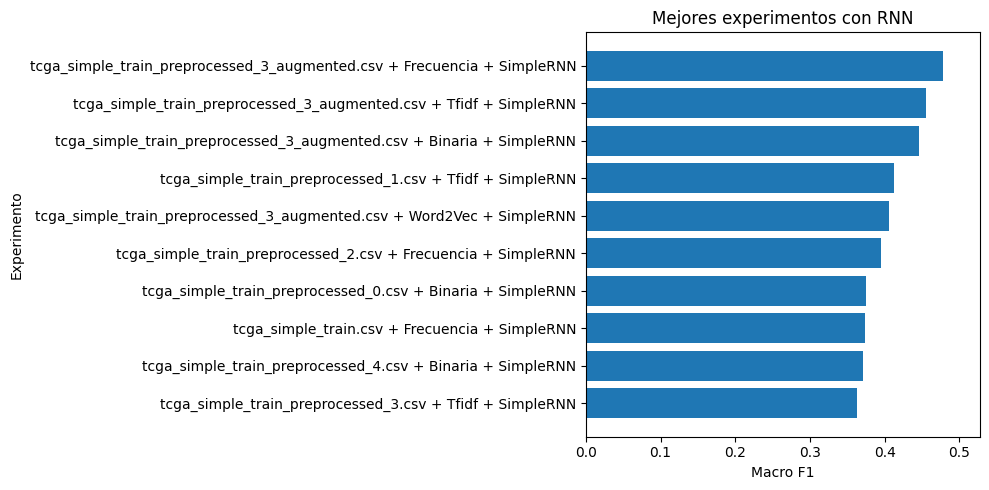

In [21]:
import matplotlib.pyplot as plt

# Nos quedamos con los 10 mejores experimentos
top = df_resultados.sort_values("Macro_F1", ascending=False).head(10).copy()

# Creamos un nombre legible del experimento
top["experiment"] = (
    top["Dataset"].astype(str)
    + " + "
    + top["Vectorizacion"].astype(str)
    + " + "
    + top["Modelo"].astype(str)
)

plt.figure(figsize=(10, 5))

plt.barh(
    top["experiment"],
    top["Macro_F1"]
)

plt.xlabel("Macro F1")
plt.ylabel("Experimento")
plt.title("Mejores experimentos con RNN")
plt.gca().invert_yaxis()
plt.xlim(0, max(top["Macro_F1"]) + 0.05)

plt.tight_layout()
plt.show()

## 7 - Mejor experimento

Aquí se muestra el mejor resultado obtenido y el informe de clasificación por clase.

In [22]:
best_info

{'Dataset': 'tcga_simple_train_preprocessed_3_augmented.csv',
 'Vectorizacion': 'Frecuencia',
 'Macro_F1': 0.4774890899156936}

In [23]:
if best_y_true is not None:
    print(classification_report(
        best_y_true,
        best_y_pred,
        target_names=best_labels
    ))
else:
    print("No se ha entrenado ningún modelo correctamente.")

              precision    recall  f1-score   support

          T1       0.36      0.60      0.45       300
          T2       0.37      0.31      0.33       350
          T3       0.39      0.31      0.34       317
          T4       0.91      0.69      0.79       312

    accuracy                           0.47      1279
   macro avg       0.51      0.48      0.48      1279
weighted avg       0.50      0.47      0.47      1279



## 8 - Matriz de confusión del mejor experimento

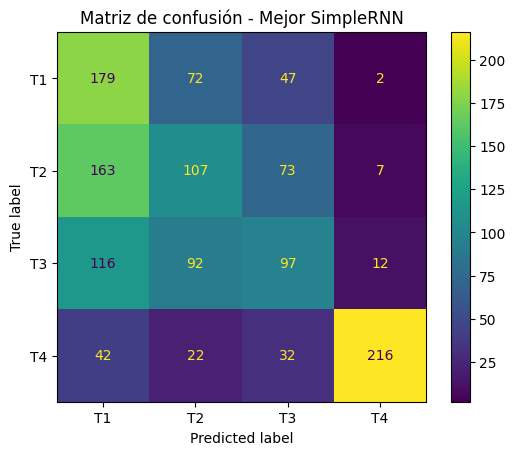

In [24]:
if best_y_true is not None:
    cm = confusion_matrix(best_y_true, best_y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=best_labels
    )

    disp.plot()
    plt.title("Matriz de confusión - Mejor SimpleRNN")
    plt.show()